In [134]:
import pandas as pd
import numpy as np
import importlib
import jenkspy
from tqdm import tqdm

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score
import networkx as nx
import community as community_louvain

import plotly.express as px
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

import utility_functions as uf

In [3]:
importlib.reload(uf)

<module 'utility_functions' from '/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py'>

In [116]:
year = 2022
mode = "individual"

n_cap = 2000

df_cs_full = pd.read_csv(uf.PATH+f"df_country_subfield/{mode}_{year}.csv", index_col=0)

country_idx = df_cs_full.sum(axis=1).to_frame("total").query("total > @n_cap").index
df_cs = df_cs_full.loc[country_idx]

n_articles = df_cs.sum(axis=1)

df_prob_full = df_cs_full.div(df_cs_full.sum(axis=1), axis=0)
df_prob = df_cs.div(df_cs.sum(axis=1), axis=0)

subfield_tree = uf.get_subfield_tree(uf.df_topics)

df_dist_full = uf.get_w1_distances(subfield_tree, df_prob_full)
df_dist = uf.get_w1_distances(subfield_tree, df_prob)

np.fill_diagonal(df_dist_full.values, np.nan)
np.fill_diagonal(df_dist.values, np.nan)

In [117]:
df_cs_yearly_full = pd.read_csv(uf.PATH+"df_cs_yearly.csv", index_col=[0, 1, 2]).xs(mode, level=2)

In [118]:
n_years = 5

df_cs_roll_yearly = (
    df_cs_yearly_full
    .sort_index()
    .groupby(level=0)
    .rolling(n_years, min_periods = 1).sum()
    .reset_index(level=0, drop=True)
)
df_prob_roll_yearly = df_cs_roll_yearly.div(df_cs_roll_yearly.sum(axis=1), axis=0)

In [119]:
cap_articles = 2000
# cap_articles = 0
index_capped = df_cs_roll_yearly.sum(axis=1).to_frame("total").query("total >= @cap_articles").index

In [120]:
df_dist_roll = uf.get_w1_distances(subfield_tree, df_prob_roll_yearly.xs(year, level=1))

country_list = df_cs_roll_yearly.xs(year, level=1).sum(axis=1).to_frame("total").query("total >= @cap_articles").index.to_list()
df_dist_roll_capped = uf.get_w1_distances(subfield_tree, df_prob_roll_yearly.xs(year, level=1).loc[country_list])
np.fill_diagonal(df_dist_roll.values, np.nan)
np.fill_diagonal(df_dist_roll_capped.values, np.nan)

In [121]:
df_country_stats = pd.read_csv(uf.PATH+f"df_stats_country_yearly.csv", index_col=0)

In [132]:
print("N countries raw: ", (df_cs_full.sum(axis=1) >= cap_articles).sum())
print("N countries rolling: ", (df_cs_roll_yearly.xs(year, level=1).sum(axis=1) >= cap_articles).sum())

N countries raw:  81
N countries rolling:  119


In [122]:
(
    df_country_stats
    .drop_duplicates()
    .query("year == @year and mode == @mode")
    .drop(columns=["year", "mode"])
    .merge(df_dist_full.mean().to_frame("mean_w1_full"), left_index=True, right_index=True, how="left")
    .merge(df_dist.mean().to_frame("mean_w1"), left_index=True, right_index=True, how="left")
    .merge(df_dist_roll.mean().to_frame("mean_w1_roll"), left_index=True, right_index=True, how="left")
    .merge(df_dist_roll_capped.mean().to_frame("mean_w1_roll_capped"), left_index=True, right_index=True, how="left")
    # .merge(df_dist_energy.mean().to_frame("mean_dist_energy"), left_index=True, right_index=True, how="left")
    # .merge(df_dist_test.mean().to_frame("mean_dist_test"), left_index=True, right_index=True, how="left")
).corr()

,entropy,norm_entropy,total_articles,log_total_articles,gini,mean_w1_full,mean_w1,mean_w1_roll,mean_w1_roll_capped
entropy,1.000000,1.000000,0.165844,0.854769,0.808489,-0.712621,-0.614384,-0.515093,-0.477443
norm_entropy,1.000000,1.000000,0.165844,0.854769,0.808489,-0.712621,-0.614384,-0.515093,-0.477443
total_articles,0.165844,0.165844,1.000000,0.444558,0.239458,-0.012958,0.234584,0.030589,0.196214
log_total_articles,0.854769,0.854769,0.444558,1.000000,0.872870,-0.516034,0.058159,-0.371739,-0.069674
gini,0.808489,0.808489,0.239458,0.872870,1.000000,-0.472208,0.616555,-0.312812,0.286639
mean_w1_full,-0.712621,-0.712621,-0.012958,-0.516034,-0.472208,1.000000,0.825340,0.839364,0.862423
mean_w1,-0.614384,-0.614384,0.234584,0.058159,0.616555,0.825340,1.000000,0.741363,0.899556
mean_w1_roll,-0.515093,-0.515093,0.030589,-0.371739,-0.312812,0.839364,0.741363,1.000000,0.904363
mean_w1_roll_capped,-0.477443,-0.477443,0.196214,-0.069674,0.286639,0.862423,0.899556,0.904363,1.000000


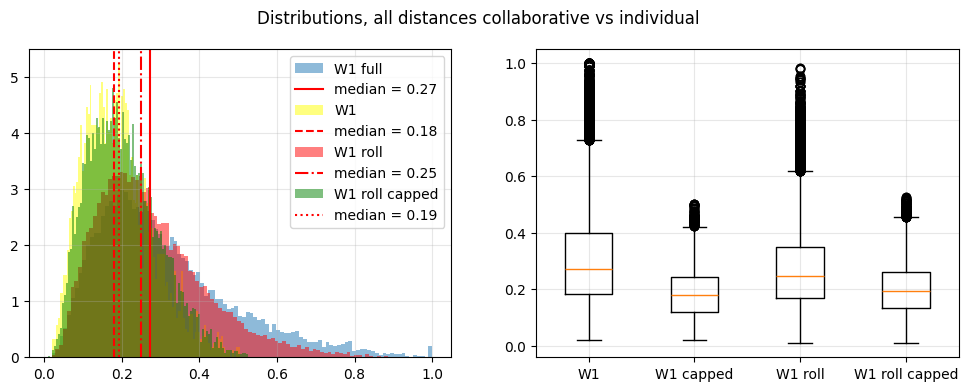

In [123]:
fig, (ax1, ax2) =plt.subplots(ncols=2, nrows=1, figsize=(12, 4))

data1 = df_dist_full.values.flatten()
data1 = data1[~np.isnan(data1)]

data2 = df_dist.values.flatten()
data2 = data2[~np.isnan(data2)]

data3 = df_dist_roll.values.flatten()
data3 = data3[~np.isnan(data3)]

data4 = df_dist_roll_capped.values.flatten()
data4 = data4[~np.isnan(data4)]


ax1.hist(data1, bins=100, alpha=0.5, label="W1 full", density=True)
ax1.axvline(np.median(data1), color="red", label=f"median = {round(np.median(data1), 2)}")
ax1.hist(data2, bins=100, alpha=0.5, label="W1", density=True, color="yellow")
ax1.axvline(np.median(data2), color="red", label=f"median = {round(np.median(data2), 2)}", linestyle="--")
ax1.hist(data3, bins=100, alpha=0.5, label="W1 roll", density=True, color="red")
ax1.axvline(np.median(data3), color="red", label=f"median = {round(np.median(data3), 2)}", linestyle="-.")
ax1.hist(data4, bins=100, alpha=0.5, label="W1 roll capped", density=True, color="green")
ax1.axvline(np.median(data4), color="red", label=f"median = {round(np.median(data4), 2)}", linestyle=":")
ax1.legend()
ax1.grid(alpha=0.3)
# plt.show()

plt.subplot(1, 2, 2)


# ax2.boxplot([data1], tick_labels=["W1"])
# ax2.set_xticks([1], ["W1"])
ax2.boxplot([data1, data2, data3, data4], tick_labels=["W1 full", "W1", "W1 roll", "W1 roll capped"])
ax2.set_xticks([1, 2, 3, 4], ["W1", "W1 capped", "W1 roll", "W1 roll capped"])
ax2.grid(alpha=0.3)

plt.suptitle("Distributions, all distances collaborative vs individual")
plt.show()

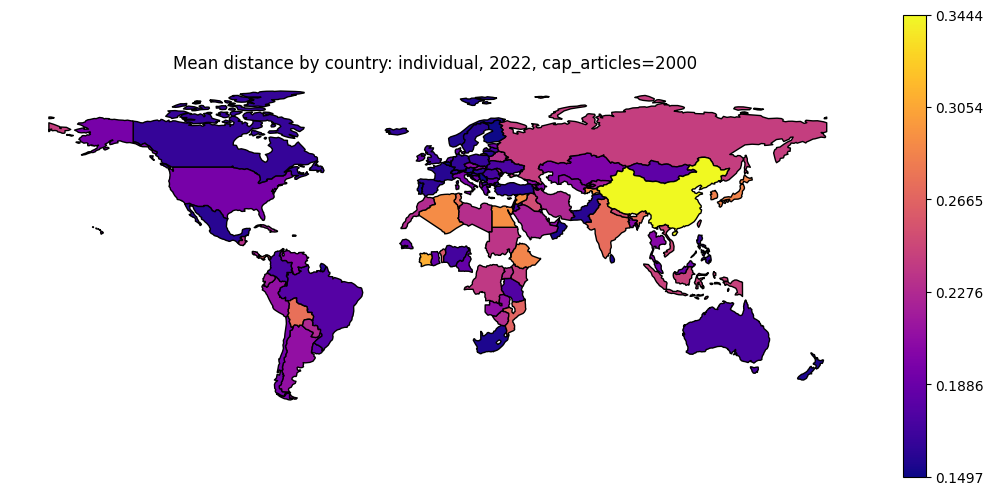

In [124]:
_, _ = uf.plot_map_continuous(
    df_dist_roll_capped.mean().to_frame("cluster").merge(uf.df_country[["alpha-2", "alpha-3"]], left_index=True, right_on="alpha-2"),
    "cluster", country_column="alpha-3", title=f"Mean distance by country: {mode}, {year}, cap_articles={cap_articles}")

In [125]:
# y_labels = df_cs.sum(axis=1).sort_values(ascending=False).index.to_list()
y_labels = df_cs_roll_yearly.xs(year, level=1).sum(axis=1).sort_values(ascending=False).index.to_list()
y_labels = (
    df_cs_roll_yearly
    .xs(year, level=1)
    .sum(axis=1).to_frame("total")
    .query(f"total >= @cap_articles")
    .sort_values("total", ascending=False)
    .index.to_list())

uf.plotly_heatmap(
    # df_dist.loc[y_labels, y_labels],
    df_dist_roll.loc[y_labels, y_labels],
    x_labels=y_labels,
    y_labels=y_labels,
    # z_min=0, z_max=1,
    colorscale="non-symmetrical",
    x_type="country",
    y_type="country",
    title=f"Distance between countries, {mode}, {year}, cap_articles = {cap_articles}",
    line_height=10
)

# W1-distance based clustering

## Calculate stats

In [66]:
# year = 2023
# mode = "individual"

In [67]:
# df_cs = pd.read_csv(uf.PATH+f"df_country_subfield/{mode}_{year}.csv", index_col=0)
# df_prob = df_cs.div(df_cs.sum(axis=1), axis=0)

In [310]:
clustering_algorithms = []

In [311]:
# df_dist = uf.get_w1_distances(subfield_tree, df_prob)
# np.fill_diagonal(df_dist.values, np.nan)

In [312]:
df_test = df_dist_roll_capped

In [313]:
D = df_test.fillna(0).values
# D = np.atan(3*df_dist.fillna(0).values)

In [314]:
# plt.hist(df_dist.values.flatten(), alpha=0.5)
# plt.hist(np.atan(3*df_dist.values.flatten()), alpha=0.5)

In [315]:
similarity = 1 / (1 + D)

G = nx.from_numpy_array(similarity)

np.random.seed(0)

partition = community_louvain.best_partition(G, weight="weight")
labels = np.array(list(partition.values()))

clustering_algorithms.append({
    "name": "louvain",
    "note": "Optimizing modularity",
    "param": None,
    "param_value": None,
    "silhouette_score": silhouette_score(D, labels, metric="precomputed"),
    "dunn_index": uf.dunn_index(df_test, labels),
    "n_clusters": len(set(labels)),
    "max_cluster": max(pd.Series(labels).value_counts()),
    "max_cluster_percent": max(pd.Series(labels).value_counts()) / len(labels),
    "min_cluster": min(pd.Series(labels).value_counts()),
    "min_cluster_percent": min(pd.Series(labels).value_counts()) / len(labels),
})

# print("Clusters: ")
# print(pd.Series(labels).value_counts())
# print()

# print("Silhouette Score: ", silhouette_score(D, list(labels), metric="precomputed"))
# print("Dunn Index: ", uf.dunn_index(df_test, labels))

In [316]:
condensed_D = squareform(D)

method = "average"
param = "distance"
param_value_list = [0.15, 0.2, 0.3, 0.4, 0.5]

Z = linkage(condensed_D, method=method)

for param_value in param_value_list:
    try:
        np.random.seed(0)
        labels = fcluster(Z, t=param_value, criterion=param)

        # print("Clusters: ")
        # print(pd.Series(labels).value_counts())
        # print()

        # print("Silhouette Score: ", silhouette_score(D, labels, metric="precomputed"))
        # print("Dunn Index: ", uf.dunn_index(df_dist, labels))

        clustering_algorithms.append({
            "name": "linkage",
            "note": "Hierarchical, {}".format(method),
                "param": param,
                "param_value": param_value,
                "silhouette_score": silhouette_score(D, labels, metric="precomputed"),
                "dunn_index": uf.dunn_index(df_test, labels),
                "n_clusters": len(set(labels)),
                "max_cluster": max(pd.Series(labels).value_counts()),
                "max_cluster_percent": max(pd.Series(labels).value_counts()) / len(labels),
                "min_cluster": min(pd.Series(labels).value_counts()),
                "min_cluster_percent": min(pd.Series(labels).value_counts()) / len(labels),
            })
    except Exception as e:
        print(e)

Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)
Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)
Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)


In [317]:
# condensed_D = squareform(D)

# method = "average"
# param = "maxclust"
# param_value_list = [2, 3, 4, 5, 6]

# Z = linkage(condensed_D, method=method)

# for param_value in param_value_list:
#     np.random.seed(0)
#     labels = fcluster(Z, t=param_value, criterion=param)

#     # print("Clusters: ")
#     # print(pd.Series(labels).value_counts())
#     # print()

#     # print("Silhouette Score: ", silhouette_score(D, labels, metric="precomputed"))
#     # print("Dunn Index: ", uf.dunn_index(df_dist, labels))

#     clustering_algorithms.append({
#         "name": "linkage",
#         "note": "Hierarchical, {}".format(method),
#         "param": param,
#         "param_value": param_value,
#         "silhouette_score": silhouette_score(D, labels, metric="precomputed"),
#         "dunn_index": uf.dunn_index(df_test, labels),
#         "n_clusters": len(set(labels)),
#         "max_cluster": max(pd.Series(labels).value_counts()),
#         "max_cluster_percent": max(pd.Series(labels).value_counts()) / len(labels),
#         "min_cluster": min(pd.Series(labels).value_counts()),
#         "min_cluster_percent": min(pd.Series(labels).value_counts()) / len(labels),
#     })

In [318]:
# from sklearn.cluster import AgglomerativeClustering

# param = "distance"
# param_value_list = [0.15, 0.2, 0.3, 0.4, 0.5]
# for param_value in param_value_list:
#     try:
#         np.random.seed(0)
#         model = AgglomerativeClustering(n_clusters=None, distance_threshold=param_value, metric='precomputed', linkage='average')

#         labels = model.fit_predict(D)

#         clustering_algorithms.append({
#             "name": "agglomearative",
#             "note": "Hierarchical, {}".format(method),
#             "param": param,
#             "param_value": param_value,
#             "silhouette_score": silhouette_score(D, labels, metric="precomputed"),
#             "dunn_index": uf.dunn_index(df_test, labels),
#             "n_clusters": len(set(labels)),
#             "max_cluster": max(pd.Series(labels).value_counts()),
#             "max_cluster_percent": max(pd.Series(labels).value_counts()) / len(labels),
#             "min_cluster": min(pd.Series(labels).value_counts()),
#             "min_cluster_percent": min(pd.Series(labels).value_counts()) / len(labels),
#         })
#     except Exception as e:
#         print(e)

In [319]:
# from sklearn.cluster import AgglomerativeClustering

# param = "n_clusters"
# param_value_list = [2, 3, 4, 5, 6]
# for param_value in param_value_list:
#     np.random.seed(0)
#     model = AgglomerativeClustering(n_clusters=param_value, metric='precomputed', linkage='average')

#     labels = model.fit_predict(D)

#     # print("Clusters: ")
#     # print(pd.Series(labels).value_counts())
#     # print()
#     # print("Silhouette Score: ", silhouette_score(D, labels, metric="precomputed"))
#     # print("Dunn Index: ", uf.dunn_index(df_dist, labels))

#     clustering_algorithms.append({
#         "name": "agglomearative",
#         "note": "Hierarchical, {}".format(method),
#         "param": param,
#         "param_value": param_value,
#         "silhouette_score": silhouette_score(D, labels, metric="precomputed"),
#         "dunn_index": uf.dunn_index(df_test, labels),
#         "n_clusters": len(set(labels)),
#         "max_cluster": max(pd.Series(labels).value_counts()),
#         "max_cluster_percent": max(pd.Series(labels).value_counts()) / len(labels),
#         "min_cluster": min(pd.Series(labels).value_counts()),
#         "min_cluster_percent": min(pd.Series(labels).value_counts()) / len(labels),
#     })

In [320]:
# from sklearn.cluster import DBSCAN

# param="eps"
# param_value_list = [0.05, 0.1, 0.15, 0.2]
# for param_value in param_value_list:
#     try:
#         np.random.seed(0)
#         model = DBSCAN(eps=param_value, min_samples=10, metric='precomputed')
#         labels = model.fit_predict(D)

#         clustering_algorithms.append({
#             "name": "dbscan",
#             "note": "Density-based, {}, min_samples=10".format(method, param_value),
#             "param": param,
#             "param_value": param_value,
#             "silhouette_score": silhouette_score(D, labels, metric="precomputed"),
#             "dunn_index": uf.dunn_index(df_test, labels),
#             "n_clusters": len(set(labels)),
#             "max_cluster": max(pd.Series(labels).value_counts()),
#             "max_cluster_percent": max(pd.Series(labels).value_counts()) / len(labels),
#             "min_cluster": min(pd.Series(labels).value_counts()),
#             "min_cluster_percent": min(pd.Series(labels).value_counts()) / len(labels),
#         })
#     except Exception as e:
#         print(e)

In [321]:
# from sklearn.cluster import DBSCAN

# param="min_samples"
# param_value_list = [10, 20, 30, 40]

# for param_value in param_value_list:
#     try:
#         np.random.seed(0)
#         model = DBSCAN(eps=0.2, min_samples=param_value, metric='precomputed')
#         labels = model.fit_predict(D)

#         clustering_algorithms.append({
#             "name": "dbscan",
#             "note": "Density-based, {}, eps=0.2".format(method),
#             "param": param,
#             "param_value": param_value,
#             "silhouette_score": silhouette_score(D, labels, metric="precomputed"),
#             "dunn_index": uf.dunn_index(df_test, labels),
#             "n_clusters": len(set(labels)),
#             "max_cluster": max(pd.Series(labels).value_counts()),
#             "max_cluster_percent": max(pd.Series(labels).value_counts()) / len(labels),
#             "min_cluster": min(pd.Series(labels).value_counts()),
#             "min_cluster_percent": min(pd.Series(labels).value_counts()) / len(labels),
#         })
#     except Exception as e:
#         print(e)

In [322]:
import kmedoids

param = "n_clusters"
param_value_list = [2, 3, 4, 5, 6]
# param_value_list = [4]


for param_value in param_value_list:
    np.random.seed(0)
    c = kmedoids.fasterpam(D, param_value)
    # print("Loss is:", c.loss)

    labels = c.labels

    clustering_algorithms.append({
        "name": "k-medoids",
        "note": "K-medoids",
        "param": param,
        "param_value": param_value,
        "silhouette_score": silhouette_score(D, labels, metric="precomputed"),
        "dunn_index": uf.dunn_index(df_test, labels),
        "n_clusters": len(set(labels)),
        "max_cluster": max(pd.Series(labels).value_counts()),
        "max_cluster_percent": max(pd.Series(labels).value_counts()) / len(labels),
        "min_cluster": min(pd.Series(labels).value_counts()),
        "min_cluster_percent": min(pd.Series(labels).value_counts()) / len(labels),
    })

In [323]:
from sklearn.cluster import SpectralClustering
import numpy as np

# Convert distance -> similarity
sigma_list = [0.1, 0.5]
param = "n_clusters"
param_value_list = [2, 3, 4, 5, 6]
for sigma in sigma_list:
    np.random.seed(0)
    affinity = np.exp(-D**2 / (2 * sigma**2))
    for param_value in param_value_list:
        model = SpectralClustering(n_clusters=param_value, affinity='precomputed')
        labels = model.fit_predict(affinity)

        clustering_algorithms.append({
                "name": "spectral",
                "note": "K-means in sprectral space, sigma={}".format(sigma),
                "param": param,
                "param_value": param_value,
                "silhouette_score": silhouette_score(D, labels, metric="precomputed"),
                "dunn_index": uf.dunn_index(df_test, labels),
                "n_clusters": len(set(labels)),
                "max_cluster": max(pd.Series(labels).value_counts()),
                "max_cluster_percent": max(pd.Series(labels).value_counts()) / len(labels),
                "min_cluster": min(pd.Series(labels).value_counts()),
                "min_cluster_percent": min(pd.Series(labels).value_counts()) / len(labels),
            })

In [324]:
df_stats = pd.json_normalize(clustering_algorithms).drop_duplicates().assign(min_max_ratio = lambda df: df["min_cluster_percent"] / df["max_cluster_percent"])

In [325]:
# df_stats = pd.json_normalize(clustering_algorithms).drop_duplicates().assign(min_max_ratio = lambda df: df["min_cluster_percent"] / df["max_cluster_percent"],)

## Demonstration clustering stats

In [326]:
# df_stats = pd.read_csv(uf.PATH+"df_stats_clustering_algorithms.csv")
# df_stats

In [327]:
name = "dbscan"
df_stats.drop_duplicates().query("name == @name")

,name,note,param,param_value,silhouette_score,dunn_index,n_clusters,max_cluster,max_cluster_percent,min_cluster,min_cluster_percent,min_max_ratio


In [328]:
px.box(
    df_stats,
    x="name",
    y="silhouette_score",
    color="name",
    points="all",
    hover_data=["name", "silhouette_score", "dunn_index", "n_clusters", "max_cluster_percent"],
    title="Silhouette Score of Clustering Algorithms",
)

In [329]:
px.box(
    df_stats,
    x="name",
    y="dunn_index",
    color="name",
    points="all",
    hover_data=["name", "silhouette_score", "dunn_index", "n_clusters", "max_cluster", "min_cluster"],
    title="Dunn Index of Clustering Algorithms",
)

In [330]:
px.box(
    df_stats,
    x="name",
    y="max_cluster_percent",
    color="name",
    points="all",
    hover_data=["name", "silhouette_score", "dunn_index", "n_clusters", "max_cluster", "min_cluster"],
    title="Max Cluster Percent of Clustering Algorithms",
)

In [331]:
# (
#     df_stats
#     # .sort_values(by=["silhouette_score"], ascending=False)
#     # .sort_values(by=["dunn_index"], ascending=False)
#     .sort_values(by=["max_cluster_percent", "min_cluster_percent", "silhouette_score"], ascending=[True, False, False])
# )